In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv(r'D:\ML-Project\notebook\StudentsPerformance.csv')

In [3]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [4]:
df.isna().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [7]:
df.nunique()

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64

In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


Exploring Data

In [9]:
print("categories in gender variable: ",end=" ")
print(df['gender'].unique())

print("categories in race/ethnicity variable: ",end=" ")
print(df['race/ethnicity'].unique())

print("categories in parental level of education variable: ",end=" ")
print(df['parental level of education'].unique())

print("categories in lunch variable: ",end=" ")
print(df['lunch'].unique())

print("categories in test preparation course variable: ",end=" ")
print(df['test preparation course'].unique())

categories in gender variable:  <StringArray>
['female', 'male']
Length: 2, dtype: str
categories in race/ethnicity variable:  <StringArray>
['group B', 'group C', 'group A', 'group D', 'group E']
Length: 5, dtype: str
categories in parental level of education variable:  <StringArray>
[ 'bachelor's degree',       'some college',    'master's degree',
 'associate's degree',        'high school',   'some high school']
Length: 6, dtype: str
categories in lunch variable:  <StringArray>
['standard', 'free/reduced']
Length: 2, dtype: str
categories in test preparation course variable:  <StringArray>
['none', 'completed']
Length: 2, dtype: str


In [10]:
categorical_features = [
    'gender',
    'race/ethnicity',
    'parental level of education',
    'lunch',
    'test preparation course'
]

numerical_features = [
    'math score',
    'reading score',
    'writing score'
]

In [11]:
categorical_features = df.select_dtypes(include='object').columns
numerical_features = df.select_dtypes(exclude='object').columns

print("Categorical:", categorical_features)
print("Numerical:", numerical_features)

Categorical: Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course'],
      dtype='str')
Numerical: Index(['math score', 'reading score', 'writing score'], dtype='str')


## Adding columns for "Total Score" and"Average "


In [12]:
df['total_score']=df['math score']+df['reading score']+df['writing score']
df['average_score']=df['total_score']/3
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,total_score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [13]:
reading_full =df[df['reading score'] == 100]['average_score'].count()
writing_full =df[df['writing score'] == 100]['average_score'].count()
math_full =df[df['math score'] == 100]['average_score'].count()

print("Number of students with full marks in reading: ", {reading_full})
print("Number of students with full marks in writing: ", {writing_full})
print("Number of students with full marks in math: ", {math_full})

Number of students with full marks in reading:  {np.int64(17)}
Number of students with full marks in writing:  {np.int64(14)}
Number of students with full marks in math:  {np.int64(7)}


In [14]:
reading_less_20 =df[df['reading score'] < 20]['average_score'].count()
writing_less_20 =df[df['writing score'] < 20]['average_score'].count()
math_less_20 =df[df['math score'] < 20]['average_score'].count()

print("Number of students with less than 20 marks in reading: ", {reading_less_20})
print("Number of students with less than 20 marks in writing: ", {writing_less_20})
print("Number of students with less than 20 marks in math: ", {math_less_20})

Number of students with less than 20 marks in reading:  {np.int64(1)}
Number of students with less than 20 marks in writing:  {np.int64(3)}
Number of students with less than 20 marks in math:  {np.int64(4)}


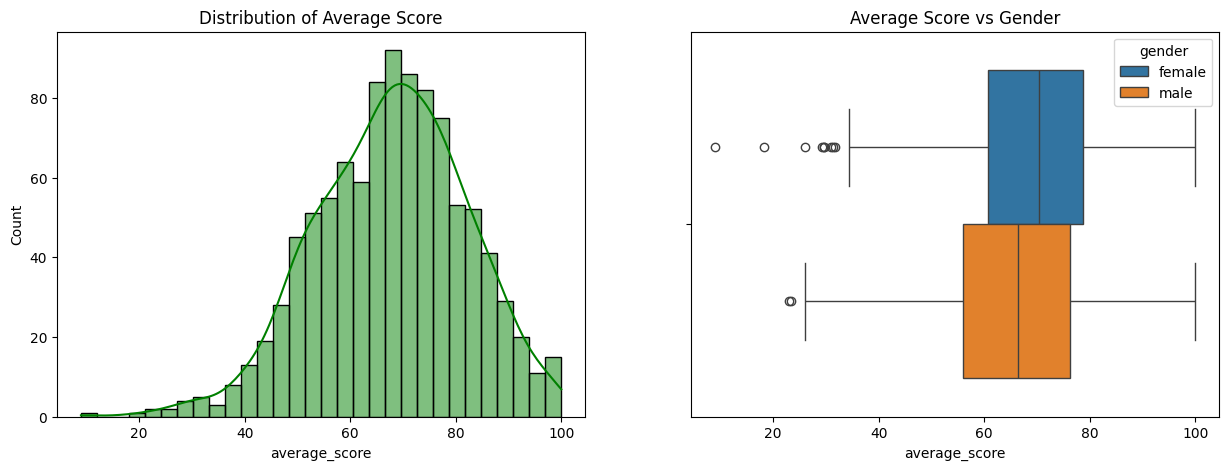

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axs = plt.subplots(1, 2, figsize=(15,5))

# Histogram
sns.histplot(data=df, x='average_score', bins=30, kde=True, color='g', ax=axs[0])
axs[0].set_title('Distribution of Average Score')

# Boxplot
sns.boxplot(data=df, x='average_score', hue='gender', ax=axs[1])
axs[1].set_title('Average Score vs Gender')

plt.show()

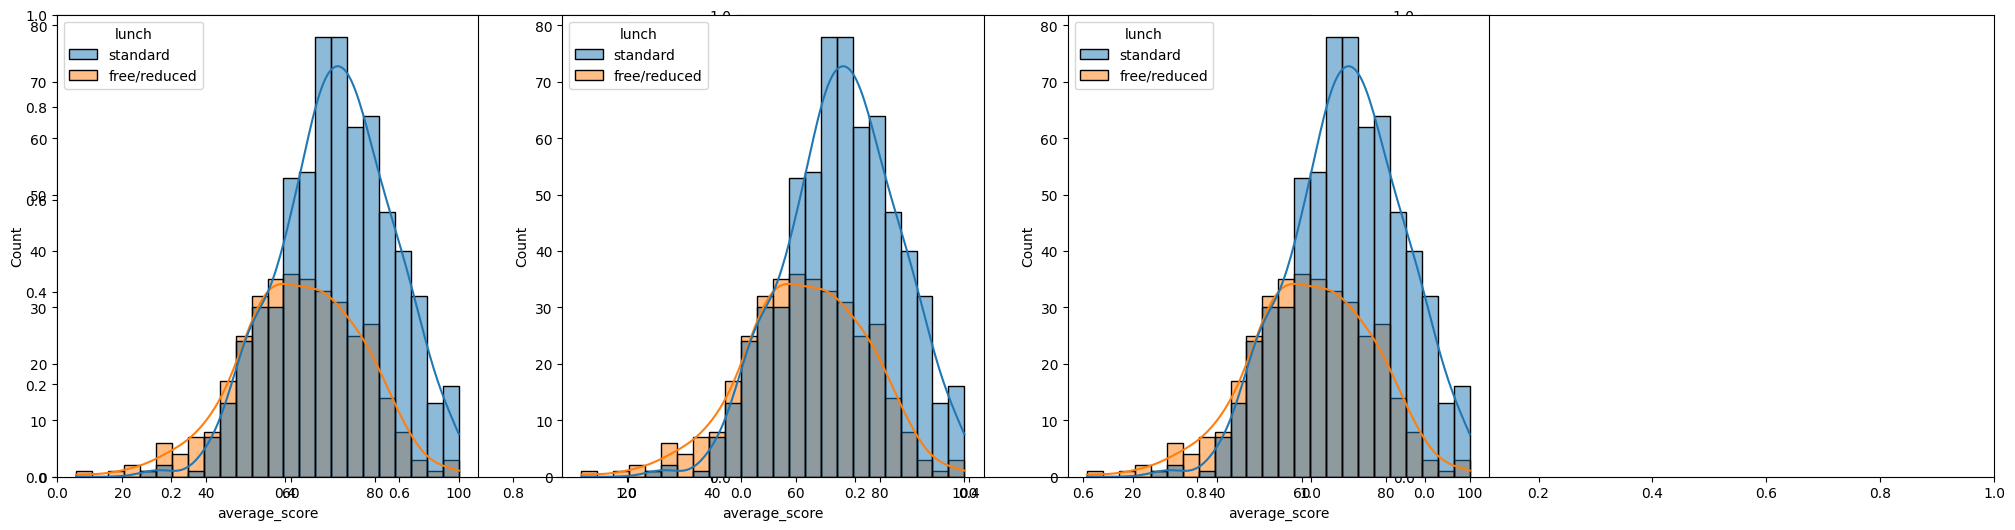

In [16]:
## female students tend to perform well then male
plt.subplots(1,3,figsize=(25,6))
plt.subplot(141)
sns.histplot(data=df, x='average_score', kde=True, hue='lunch')
plt.subplot(142)
sns.histplot(data=df, x='average_score', kde=True, hue='lunch')
plt.subplot(143)
sns.histplot(data=df, x='average_score', kde=True, hue='lunch')
plt.show()

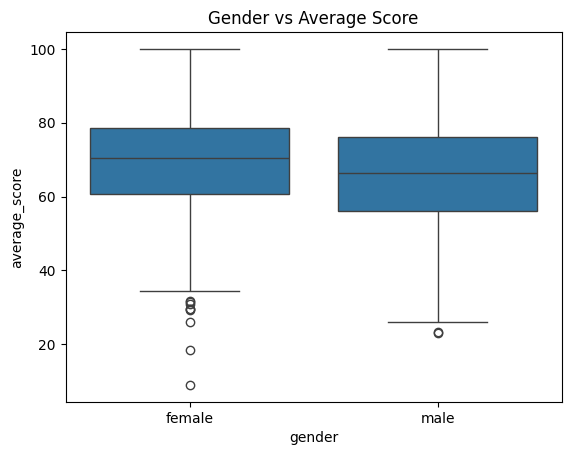

In [17]:
sns.boxplot(data=df, x='gender', y='average_score')
plt.title("Gender vs Average Score")
plt.show()

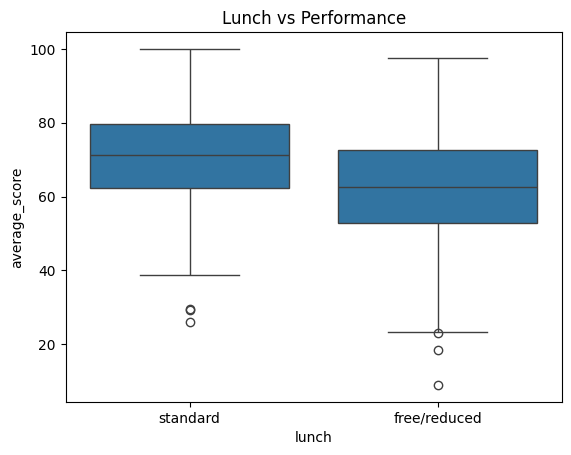

In [18]:
sns.boxplot(data=df, x='lunch', y='average_score')
plt.title("Lunch vs Performance")
plt.show()

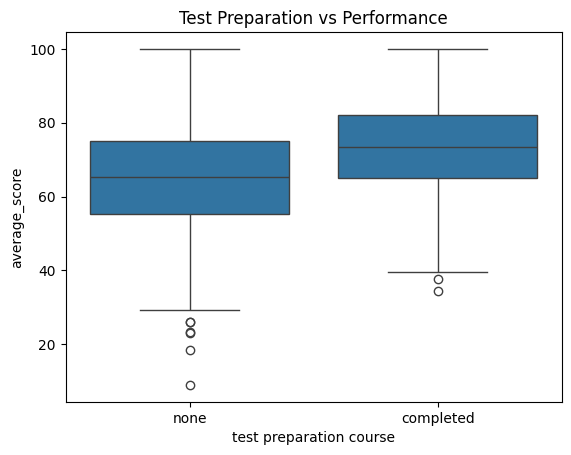

In [19]:
sns.boxplot(data=df, x='test preparation course', y='average_score')
plt.title("Test Preparation vs Performance")
plt.show()

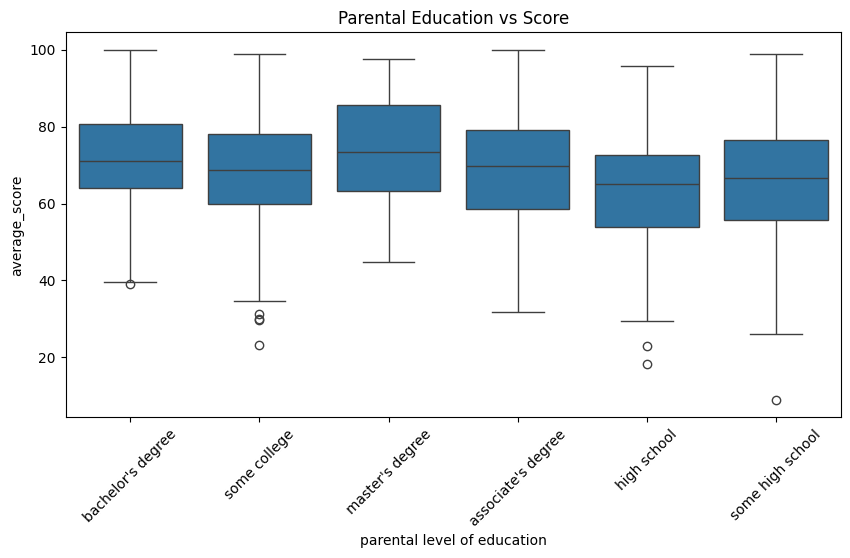

In [20]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df, x='parental level of education', y='average_score')
plt.xticks(rotation=45)
plt.title("Parental Education vs Score")
plt.show()

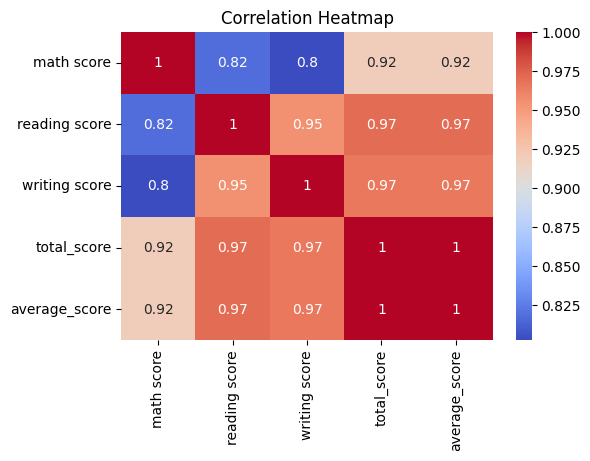

In [21]:
plt.figure(figsize=(6,4))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

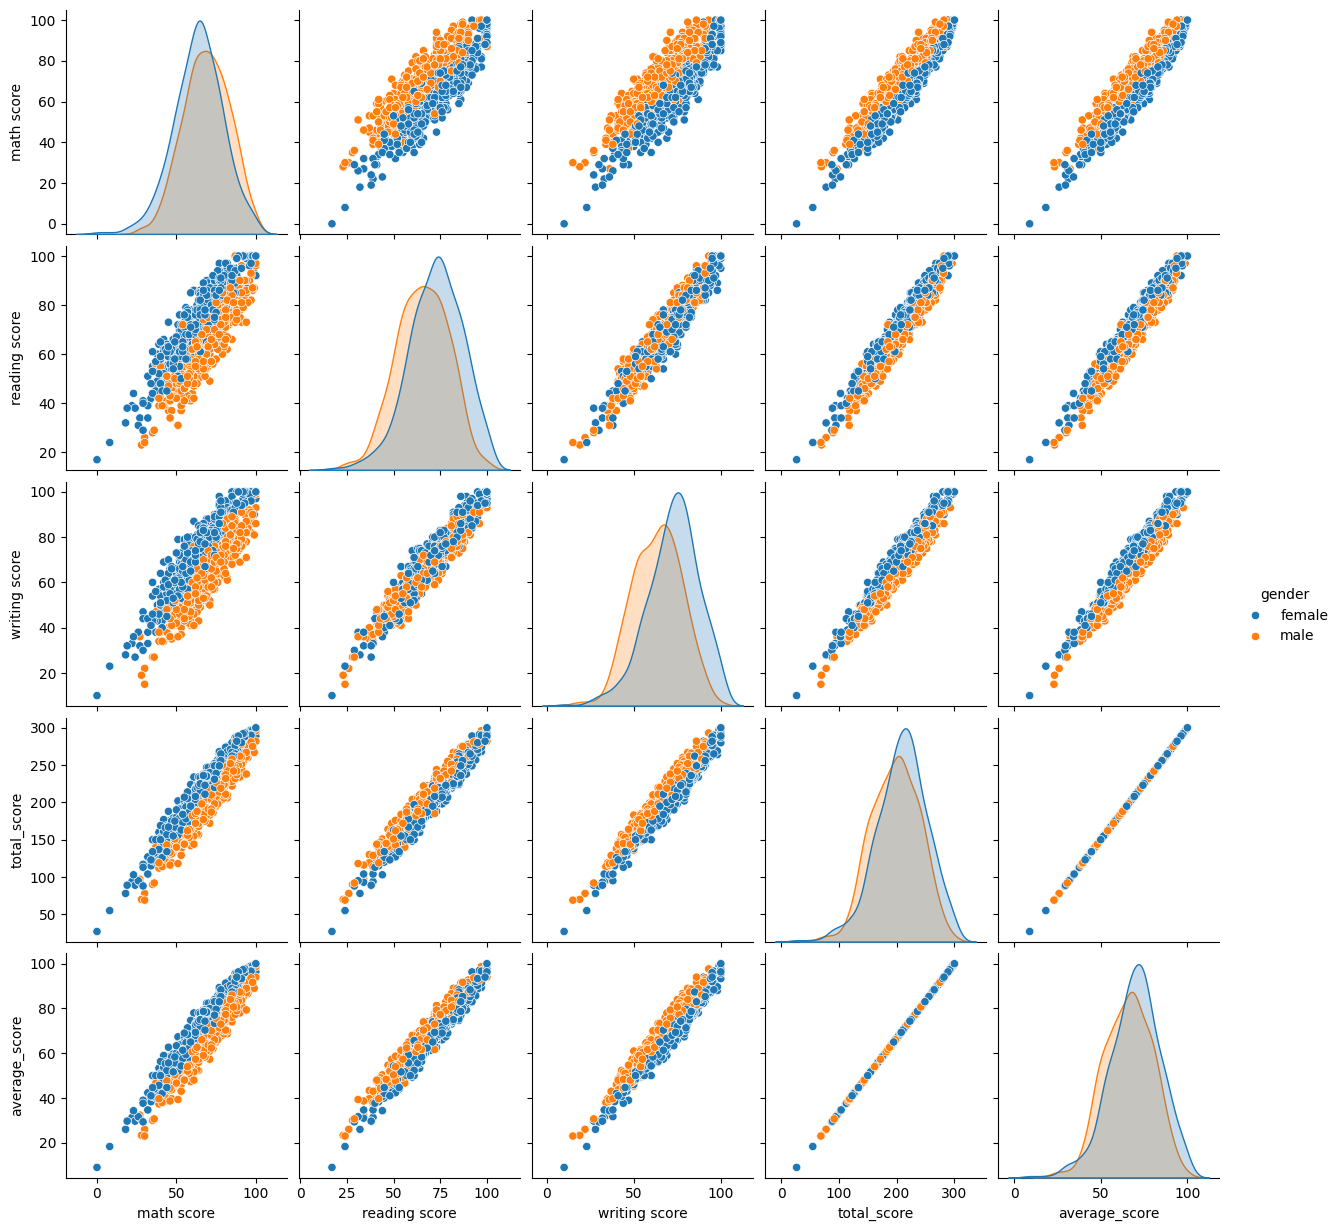

In [22]:
sns.pairplot(df, hue='gender')
plt.show()

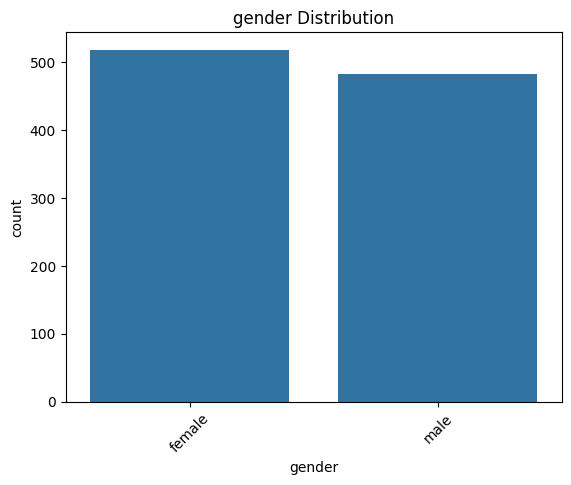

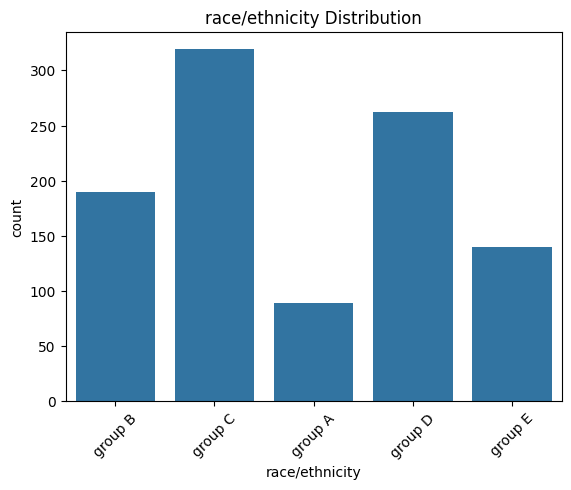

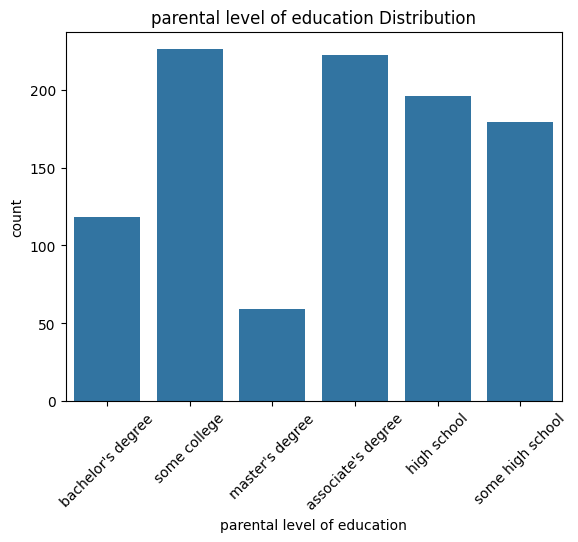

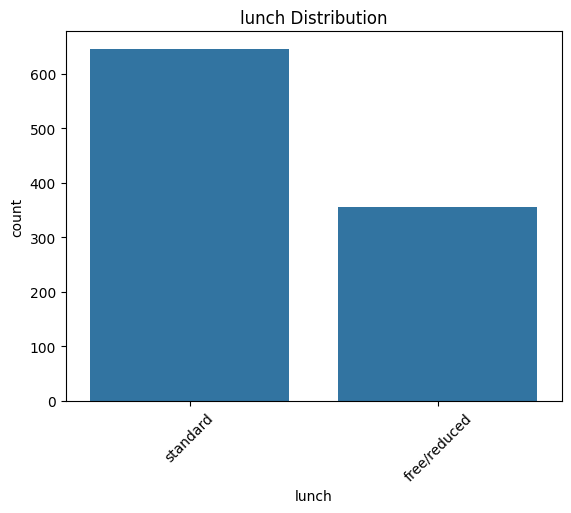

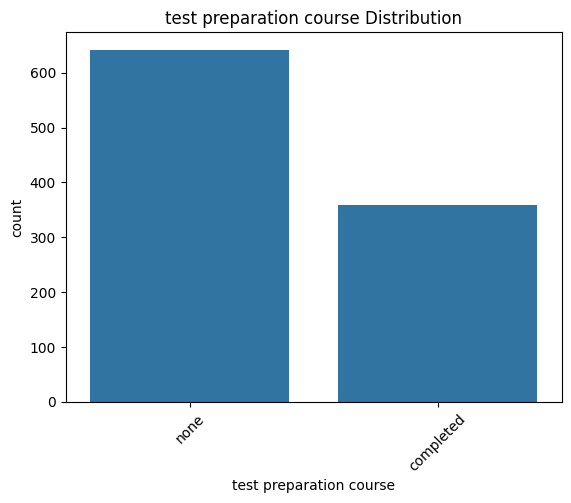

In [23]:
for col in categorical_features:
    sns.countplot(data=df, x=col)
    plt.xticks(rotation=45)
    plt.title(f"{col} Distribution")
    plt.show()

In [24]:
df.groupby('gender')['average_score'].mean()
df.groupby('lunch')['average_score'].mean()
df.groupby('test preparation course')['average_score'].mean()

test preparation course
completed    72.669460
none         65.038941
Name: average_score, dtype: float64